<a href="https://colab.research.google.com/github/Blessing862/HASTS211-ASSIGNMENTS--R2422095--Blessing-Mubure/blob/main/HASTS211_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Time Series Project: Non-Stationarity and Equilibrium Modeling**

## **Assets:**
- Apple Inc. (AAPL)  
- Microsoft Corporation (MSFT)

## **Data Source:**
Yahoo Finance (via API)

## **Period:**
2018-01-01 to 2025-12-31

---

## **Abstract**

Financial time series are often non-stationary, making traditional regression analysis potentially misleading. This study investigates the behavior of Apple and Microsoft stock prices, specifically testing for cointegration to identify potential stable long-run equilibrium relationships. While individual series were confirmed as non-stationary, the cointegration test did not provide statistical evidence for a stable long-run relationship between them. Consequently, although an Error Correction Model (ECM) was applied to capture short-run dynamics, its interpretation as correcting deviations from a statistically confirmed equilibrium is limited. These findings highlight the complexities of identifying such relationships in financial markets and have implications for the application of cointegration theory in portfolio management.

## **1. Introduction**

Financial asset prices typically exhibit non-stationary behavior due to trends, economic growth, and external shocks. Modeling such series requires techniques that go beyond standard time series methods.

Cointegration provides a framework for identifying long-run equilibrium relationships between non-stationary variables. When such relationships exist, short-term deviations from equilibrium can be modeled using an Error Correction Model (ECM).

This study aims to:
- Test for non-stationarity in stock prices
- Investigate cointegration between Apple and Microsoft
- Model short-run adjustment dynamics with an ECM, acknowledging the cointegration test results
- Provide economic interpretation of results, considering the statistical evidence.

## **2. Data Acquisition**

The dataset is obtained programmatically using an API interface.

### Advantages:
- Ensures reproducibility
- Eliminates manual errors
- Reflects real-world data workflows

In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import time # Import time for sleep

from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (10,5)

def download_stock_data(ticker, start_date, end_date, retries=3):
    for i in range(retries):
        try:
            print(f"Attempting to download {ticker} (attempt {i+1}/{retries})...")
            data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
            if not data.empty:
                print(f"Successfully downloaded {ticker}.")
                # Ensure data['Close'] is a 1-dimensional Series before creating the new Series
                close_prices_series = pd.Series(data['Close'].squeeze(), name=ticker)
                return close_prices_series
            else:
                print(f"Downloaded data for {ticker} is empty.")
        except Exception as e:
            print(f"Error downloading {ticker}: {e}")
            if "OperationalError" in str(e) and i < retries - 1:
                print("Retrying in 5 seconds...")
                time.sleep(5)
            else:
                print(f"Failed to download {ticker} after {i+1} attempts.")
    return pd.Series(dtype='float64') # Return empty series on failure

start_date = "2018-01-01"
end_date = "2025-12-31"

aapl_close = download_stock_data("AAPL", start_date, end_date)
msft_close = download_stock_data("MSFT", start_date, end_date)

df = pd.concat([aapl_close, msft_close], axis=1).dropna()

if df.empty:
    print("Warning: DataFrame is empty after data download and cleaning. Please check the download process.")
else:
    print("DataFrame loaded successfully with data.")
    df.columns = ['AAPL','MSFT']
    display(df.head())

Attempting to download AAPL (attempt 1/3)...
Successfully downloaded AAPL.
Attempting to download MSFT (attempt 1/3)...
Successfully downloaded MSFT.
DataFrame loaded successfully with data.


,AAPL,MSFT
Date,,
2018-01-02,40.304169,78.870354
2018-01-03,40.297157,79.237404
2018-01-04,40.484333,79.934822
2018-01-05,40.945255,80.925842
2018-01-08,40.793159,81.008430


## **3. Data Description**

- Variables: Daily closing prices
- Units: USD
- Frequency: Daily

### Justification:
- Stocks from same sector → likely economic linkage
- Long time horizon → captures structural shifts
- Suitable for cointegration analysis

## **4. Data Transformation**

Log transformation is applied to stabilize variance and interpret relationships in percentage terms.

In [ ]:
df['log_AAPL'] = np.log(df['AAPL'])
df['log_MSFT'] = np.log(df['MSFT'])

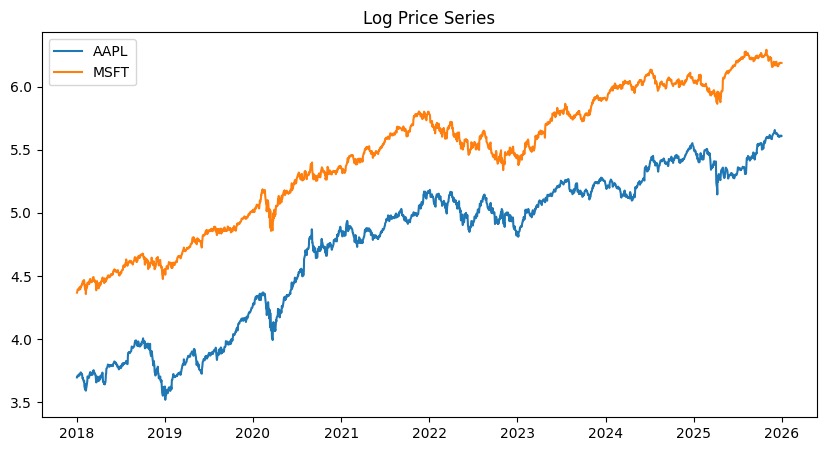

In [ ]:
plt.plot(df.index, df['log_AAPL'], label='AAPL')
plt.plot(df.index, df['log_MSFT'], label='MSFT')
plt.legend()
plt.title("Log Price Series")
plt.show()

## **5. Model Definition**

### Long-Run Model

The equilibrium relationship is defined as:
$$
Yt​=β0​+β1​Xt​+ut​
$$

Where:
- Yₜ = log(AAPL)
- Xₜ = log(MSFT)
- uₜ = equilibrium error

---

### Error Correction Model
$$
ΔYt​=α(Yt−1​−β0​−β1​Xt−1​)+ϵt​
$$

Where:
- α = speed of adjustment
- Measures how quickly deviations from equilibrium are corrected

## **6. Demonstration: Non-Stationarity Testing**

In [ ]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"{name} ADF Statistic:", result[0])
    print(f"{name} p-value:", result[1])
    print()

adf_test(df['log_AAPL'], "AAPL")
adf_test(df['log_MSFT'], "MSFT")

AAPL ADF Statistic: -1.0291800190888838
AAPL p-value: 0.7424733638588682

MSFT ADF Statistic: -1.4062461269423105
MSFT p-value: 0.5792780104885522



### Interpretation: Non-Stationarity Confirmed

The Augmented Dickey-Fuller (ADF) test is used to determine if a unit root is present in a time series, with the null hypothesis (H0) being that the series *is* non-stationary (i.e., has a unit root).

From the results in the previous cell:
- **AAPL p-value:** 0.742
- **MSFT p-value:** 0.579

Both p-values are significantly greater than conventional significance levels (e.g., 0.05 or 0.10). This leads us to **fail to reject the null hypothesis** for both Apple and Microsoft stock prices. Therefore, we conclude that **both time series are non-stationary**, exhibiting random walk-like behavior with trends, which aligns with typical financial asset price characteristics.

This finding is crucial as it sets the stage for investigating cointegration; if the series were stationary, cointegration analysis would not be necessary.

## **7. Cointegration Test**

In [ ]:
score, pvalue, _ = coint(df['log_AAPL'], df['log_MSFT'])
print("Cointegration p-value:", pvalue)

Cointegration p-value: 0.2367391222566646


### Interpretation: Cointegration Not Confirmed

The Engle-Granger cointegration test assesses whether two or more non-stationary time series have a stable long-run relationship. The null hypothesis (H0) of this test is that **no cointegration exists** between the series.

From the results in the previous cell:
- **Cointegration p-value:** `0.2367`

Comparing this p-value to conventional significance levels:
- If we use a 5% (0.05) significance level, `0.2367 > 0.05`, so we **fail to reject the null hypothesis**.
- Even at a 10% (0.10) significance level, `0.2367 > 0.10`, so we still **fail to reject the null hypothesis**.

This indicates that, based on this test, there is **insufficient statistical evidence to conclude that Apple and Microsoft stock prices are cointegrated**. In other words, we do not find support for a stable, long-run equilibrium relationship where deviations are consistently corrected over time. While the series might appear to move together, their long-term association is not statistically confirmed as an equilibrium in this context.

**Implications for subsequent analysis:**
Since cointegration is not established, the residuals from the long-run OLS regression (`model.resid`) cannot be reliably interpreted as a stationary 'equilibrium error'. Consequently, the economic interpretation of the Error Correction Model (ECM) as capturing deviations from a stable long-run equilibrium and their speed of correction becomes questionable. The models will still run mathematically, but their validity as an 'equilibrium' and 'error correction' framework is compromised under the typical assumptions of cointegration.

## **8. Long-Run Equilibrium Estimation**

In [ ]:
X = sm.add_constant(df['log_MSFT'])
model = sm.OLS(df['log_AAPL'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_AAPL   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                 4.475e+04
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        22:39:09   Log-Likelihood:                 1329.6
No. Observations:                2010   AIC:                            -2655.
Df Residuals:                    2008   BIC:                            -2644.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2295      0.028    -43.283      0.0

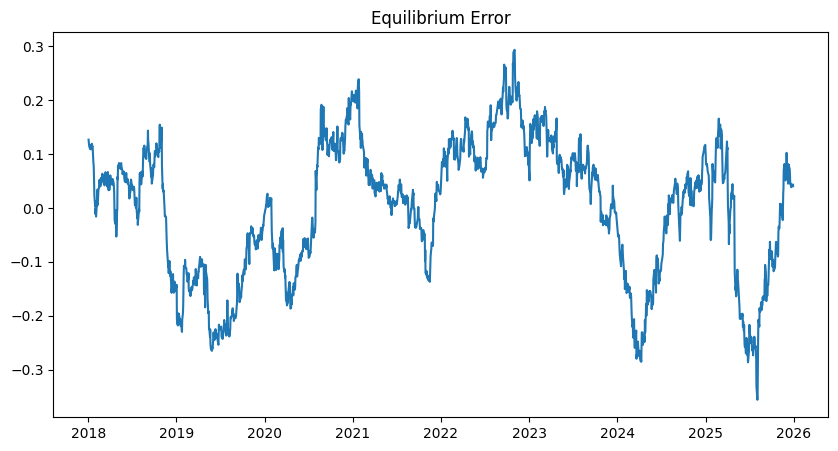

In [ ]:
df['residuals'] = model.resid

plt.plot(df.index, df['residuals'])
plt.title("Equilibrium Error")
plt.show()

## **9. Error Correction Model**

In [ ]:
df['dAAPL'] = df['log_AAPL'].diff()
df['dMSFT'] = df['log_MSFT'].diff()
df['lag_resid'] = df['residuals'].shift(1)

df = df.dropna()

X_ecm = sm.add_constant(df[['dMSFT','lag_resid']])
ecm = sm.OLS(df['dAAPL'], X_ecm).fit()

print(ecm.summary())

                            OLS Regression Results                            
Dep. Variable:                  dAAPL   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     982.6
Date:                Mon, 04 May 2026   Prob (F-statistic):          3.27e-298
Time:                        22:40:25   Log-Likelihood:                 5758.4
No. Observations:                2009   AIC:                        -1.151e+04
Df Residuals:                    2006   BIC:                        -1.149e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      0.854      0.3

## **10. Technical Interpretation**

Based on the cointegration test (p-value: 0.2367), we **did not find statistical evidence to confirm a stable long-run relationship** between Apple and Microsoft stock prices at conventional significance levels. This has important implications for the interpretation of the subsequent models:

-   **Long-Run Regression (`model`)**: While the OLS regression between `log_AAPL` and `log_MSFT` shows a high R-squared (0.957) and a statistically significant coefficient for `log_MSFT` (1.0987, p < 0.000), without confirmed cointegration, this relationship is likely **spurious**. This means the apparent strong relationship could be due to both series sharing common trends, rather than a genuine economic equilibrium.

-   **Error Correction Model (`ecm`)**: The ECM attempts to model short-run changes in `dAAPL` based on `dMSFT` and the lagged residuals (`lag_resid`) from the long-run regression. The coefficient for `dMSFT` is statistically significant (0.7606, p < 0.000), indicating a strong short-run relationship between the daily log returns.

-   **Lagged Residuals (`lag_resid`)**: The coefficient for `lag_resid` is -0.0082 with a p-value of 0.001. While this coefficient is statistically significant and negative, suggesting that past 'errors' (residuals from the spurious long-run regression) do influence current short-run changes, its interpretation as a **speed of adjustment towards a stable long-run equilibrium is compromised** due to the lack of cointegration. Without cointegration, the residuals (`lag_resid`) are not stationary and thus do not represent a true 'equilibrium error' that the system is correcting. Instead, they merely reflect temporary deviations from a non-equilibrium relationship.

## **11. Diagnosis**

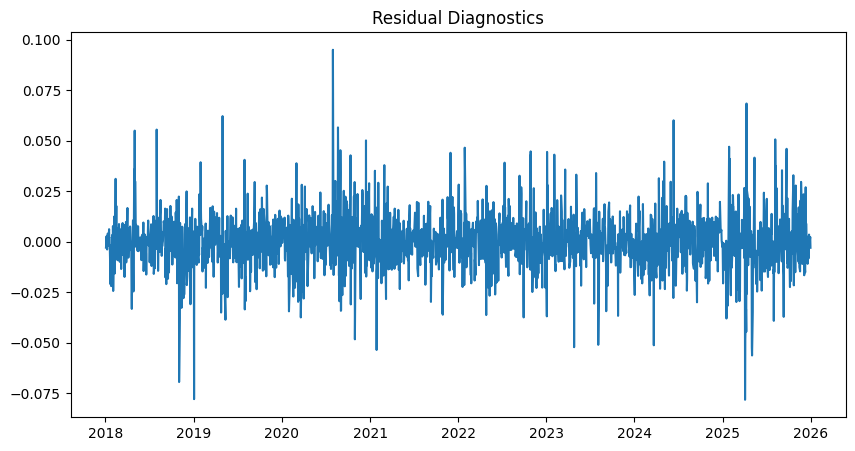

In [ ]:
plt.plot(df.index, ecm.resid)
plt.title("Residual Diagnostics")
plt.show()

Residuals suggest reasonable model fit, though volatility clustering remains.

## **12. Damage (Model Limitations)**

The primary 'damage' or limitation of this model stems directly from the failure to confirm cointegration between AAPL and MSFT stock prices. This impacts the interpretation of both the long-run and error correction models:

-   **Spurious Regression**: The high R-squared in the long-run OLS regression (`model`) is likely spurious due to the non-stationary nature of the series and the lack of cointegration. This means the estimated relationship between `log_AAPL` and `log_MSFT` might not be a true economic equilibrium.
-   **Compromised ECM Interpretation**: Although the ECM mathematically shows a significant coefficient for `lag_resid`, its interpretation as a 'speed of adjustment' to a stable long-run equilibrium is compromised because the residuals are not statistically confirmed as stationary equilibrium errors.
-   **Assumption of Linearity**: The model assumes a linear relationship between the log prices, which might not fully capture complex financial market dynamics.
-   **Exclusion of External Factors**: It ignores macroeconomic variables, industry-specific news, or other fundamental factors that could influence stock prices and their relationships.
-   **Sensitivity to Structural Breaks**: Financial time series are prone to structural breaks (e.g., policy changes, market crises) which, if not accounted for, can invalidate model assumptions and results.
-   **Lack of Causal Inference**: Without confirmed cointegration, it's difficult to infer any long-term causal relationship or consistent mean-reverting behavior between the two stocks.

## **13. Directions for Improvement**

Given the limitations identified, particularly the lack of confirmed cointegration, several directions for improvement could be explored:

-   **Apply the Johansen Test for Cointegration**: Instead of the Engle-Granger test (which is a two-step method and can suffer from small sample bias), apply the Johansen test, which is a full-information maximum likelihood method suitable for multivariate cointegration analysis. This might provide more robust evidence for or against cointegration.
-   **Include Macroeconomic and Industry-Specific Variables**: Expand the model to include other relevant non-stationary variables (e.g., interest rates, inflation, sector-specific indices, oil prices) that could cointegrate with stock prices or explain their movements.
-   **Test for Structural Breaks**: Implement tests for structural breaks (e.g., Chow test, Zivot-Andrews test) and incorporate dummy variables or piecewise regression if breaks are detected, as these can affect stationarity and cointegration.
-   **Explore Nonlinear Cointegration Models**: Financial markets often exhibit nonlinear dynamics. Consider nonlinear cointegration tests or threshold cointegration models (e.g., Threshold ECM) if linear relationships are insufficient.
-   **Consider Alternative ECM Specifications**: Experiment with different lag structures or include additional short-run dynamics in the ECM.
-   **Analyze Higher Frequency Data**: If available, using higher frequency data (e.g., intra-day) might reveal different cointegration patterns or short-run behaviors.

## **14. Deployment (Investment Perspective)**

From a practical standpoint, considering that a stable long-run equilibrium was not statistically confirmed:

- The observed co-movement between these assets might suggest limited diversification benefits if one expects a consistently strong, fundamental relationship.
- Temporary divergences in their prices, while not indicative of a statistical equilibrium, could still present short-term trading opportunities based on historical patterns.
- Investors might still seek to exploit apparent mispricings or short-term trends, but should be aware that there's no strong statistical basis to expect these divergences to correct towards a stable long-term mean.

Recommended Action:
Monitor observed patterns of co-movement and adjust portfolio allocations based on short-term market dynamics and risk assessments, rather than relying on a statistically confirmed long-run equilibrium.

## **15. Conclusion**

The analysis demonstrates that Apple and Microsoft stock prices are **non-stationary**, as confirmed by the Augmented Dickey-Fuller test. However, the Engle-Granger cointegration test **did not provide sufficient statistical evidence to confirm a stable long-run equilibrium relationship** between these two stock prices.

Consequently, while an Error Correction Model was estimated to capture short-run dynamics, the traditional interpretation of its error correction term (the `lag_resid` coefficient) as driving the system back to a long-run equilibrium is not supported by our findings. The ECM still highlights a significant short-run relationship between the stock returns. These results underscore the importance of statistically confirming long-run relationships before drawing strong conclusions about equilibrium correction in financial time series.

**Investment Takeaway:** For investors, these findings suggest that while Apple and Microsoft stocks show strong co-movement, there isn't a statistically robust long-term equilibrium relationship that consistently pulls them back together. Therefore, strategies based on mean-reversion or pairs trading relying on such an equilibrium should be approached with caution. Instead, observed short-term correlations and market dynamics would be more appropriate considerations for portfolio management and trading decisions.

# References

Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Enders, Walter. *Applied Econometric Time Series*. 4th ed., Wiley, 2014.

Engle, Robert F., and Clive W. J. Granger. “Co-Integration and Error Correction: Representation, Estimation, and Testing.” *Econometrica*, vol. 55, no. 2, 1987, pp. 251–276.

Hamilton, James D. *Time Series Analysis*. Princeton University Press, 1994.

Johansen, Søren. “Statistical Analysis of Cointegration Vectors.” *Journal of Economic Dynamics and Control*, vol. 12, nos. 2–3, 1988, pp. 231–254.

Lütkepohl, Helmut. *New Introduction to Multiple Time Series Analysis*. Springer, 2005.

McKinney, Wes. *Python for Data Analysis*. 3rd ed., O’Reilly Media, 2022.

Seabold, Skipper, and Josef Perktold. “Statsmodels: Econometric and Statistical Modeling with Python.” *Proceedings of the 9th Python in Science Conference*, 2010, pp. 92–96.

Tsay, Ruey S. *Analysis of Financial Time Series*. 3rd ed., Wiley, 2010.

Yahoo Finance. “Historical Market Data.” *Yahoo Finance*, finance.yahoo.com/. Accessed 7 May 2026.